In [2]:
from langgraph.graph import StateGraph, END

from agents.persona_generator_agent.langgraph_persona_generator import GraphState, generate_privacy_attrs_node, generate_traces_node, grade_traces_node, package_persona_node, persona_grader_node, save_package_node

# ----- Wire the graph -----
workflow = StateGraph(GraphState)

workflow.add_node("generate_privacy_attrs", generate_privacy_attrs_node)
workflow.add_node("grade_persona", persona_grader_node)
workflow.add_node("generate_traces", generate_traces_node)
workflow.add_node("grade_traces_node", grade_traces_node)
workflow.add_node("package_persona", package_persona_node)
workflow.add_node("save_package", save_package_node)

workflow.set_entry_point("generate_privacy_attrs")
workflow.add_edge("generate_privacy_attrs", "grade_persona")
workflow.add_conditional_edges(
    "grade_persona",
    lambda output: output["decision"],  # the node returns either "proceed" or "redo"
    {
        "proceed": "generate_traces",
        "redo": "generate_privacy_attrs",
    },
)
workflow.add_edge("generate_traces", "grade_traces_node")
workflow.add_conditional_edges(
    "grade_traces_node",
    lambda output: output["decision"],  # the node returns either "proceed" or "redo"
    {
        "proceed": "package_persona",
        "redo": "generate_traces",
    },
)
workflow.add_edge("package_persona", "save_package")
workflow.add_edge("save_package", END)

app = workflow.compile()

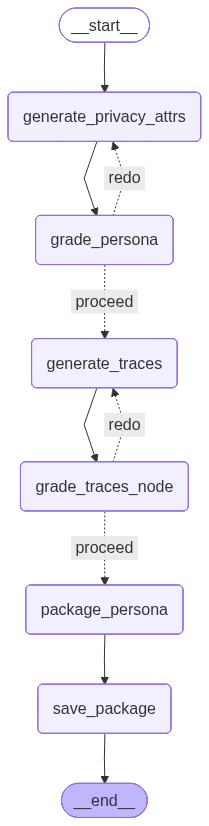

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))